# Dataset visualization

Inspects and analyzes a saved `BeamDataset` (`.pt` file) against the **current** `beam_optimization` configuration (`config/adige.py`): schema/composition, per-parameter and per-stage statistics, distributions, score, a single combined parameter/beam-state correlation matrix, and dataset coverage.

> This notebook is read-only: it only loads an existing dataset file, it does not run TraceWin and does not change anything on disk.

## 0. How this dataset was built

Every row here comes from one real TraceWin simulation, produced by `TraceWinDatasetBuilder`
(`env/dataset/tracewin_dataset_builder.py`):

1. **Sample parameters from a Gaussian centered on the machine defaults.** Independently for each of
   the `N_PARAMS` parameters: `value = default + Normal(0, sensitivity * DATASET_SCALE)`, then clipped
   to that parameter's hardware bounds (`hw_min`/`hw_max`). Parameters are drawn independently (a
   diagonal covariance, no correlation imposed at generation time) -- any correlation you see in
   section 5 is a real physics effect from TraceWin transport, not an artifact of how the samples were
   generated.
2. **Run the real simulator** on the sampled parameters (`simulator.simulate(params)`).
3. **Accept or reject.** A sample is kept if TraceWin returned a real result and either (a) the beam
   was transported successfully, or (b) all particles were lost partway through and TraceWin encoded
   that as a physics failure (the beam state is zeroed from the loss point onward) -- both outcomes are
   informative and kept. Only *technical* failures (simulator crashes, non-physical returns) are
   discarded, and the attempt is silently retried with a fresh draw.
4. **Repeat until `target_samples` accepted rows exist.** Every attempt draws from
   `np.random.default_rng(seed + attempt_index)`, so a whole build -- including which attempts failed --
   is exactly reproducible from one `seed`. Progress is checkpointed to `builder_state.json`, so an
   interrupted build resumes exactly where it left off; changing the sampling configuration (e.g. a
   different `DATASET_SCALE`) is detected and the build refuses to resume, rather than silently mixing
   two distributions in one file.
5. **Split 80/10/10** into train/val/test (shuffled with a fixed seed), saved alongside `dataset_all.pt`.

`DATASET_SCALE` is not an arbitrary width -- `exploration_scale_calculation` calibrates it to hit
roughly an **80% TraceWin success rate**, so the ~20% "all particles lost" rows you will see in
section 4 are intentional boundary-region coverage, not a building error (see also
`visualize_environments.ipynb`, which uses the same `DATASET_SCALE` for the RL environment's own reset
distribution).

In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

WORKING_DIR = Path.cwd().resolve()
if (WORKING_DIR / 'beam_optimization').is_dir():
    REPO_ROOT = WORKING_DIR
else:
    PROJECT_ROOT = WORKING_DIR
    while PROJECT_ROOT.name != 'beam_optimization' and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent
    REPO_ROOT = PROJECT_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from beam_optimization.config.adige import (
    BEAM_STATE_DIM, BEAM_STATE_FEATURES, DATASET_SCALE, ERROR_SCORE,
    N_OUTPUT_STAGES, N_PARAMS, N_STAGES, PARAMETERS, STAGE_MARKERS,
    default_params, params_to_vec, score_function_metadata, sensitivity_vec,
)
from beam_optimization.config.paths import default_dataset_path
from beam_optimization.env.dataset import BeamDataset


# A restrained, color-blind-friendly palette shared by every figure.
COLORS = {
    'blue': '#4C78A8',
    'teal': '#2A9D8F',
    'gold': '#E9A23B',
    'coral': '#E76F51',
    'ink': '#253238',
    'grid': '#D8DEE6',
}
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#AAB4C0',
    'axes.labelcolor': COLORS['ink'],
    'axes.titlecolor': COLORS['ink'],
    'axes.titleweight': 'semibold',
    'xtick.color': '#52606D',
    'ytick.color': '#52606D',
    'grid.color': COLORS['grid'],
    'grid.alpha': 0.55,
    'grid.linewidth': 0.7,
    'legend.frameon': False,
})


def style_axis(ax, grid_axis='y'):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis=grid_axis)
    ax.set_axisbelow(True)


def fmt(value):
    return f'{float(value):.6g}'


def table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |', '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    lines.extend('| ' + ' | '.join(str(cell) for cell in row) + ' |' for row in rows)
    return '\n'.join(lines)


def stage_label(index):
    """Match the beam0/marker_X convention used throughout the project."""
    if index == 0:
        return 'beam0'
    return f'marker_{STAGE_MARKERS[index]}'


def plot_grid_hist(data_list, labels, title, bins=60, ncols=6, cell_w=3.0, cell_h=2.1):
    n = len(data_list)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(cell_w * ncols, cell_h * nrows))
    axes = np.atleast_1d(axes).reshape(nrows, ncols).ravel()
    for i, ax in enumerate(axes):
        if i >= n:
            ax.axis('off')
            continue
        values = np.asarray(data_list[i], dtype=float)
        ax.hist(values, bins=bins, color=COLORS['blue'], alpha=0.90,
                edgecolor='white', linewidth=0.35)
        ax.set_title(labels[i], fontsize=7.5, pad=5)
        ax.tick_params(labelsize=6)
        style_axis(ax)
        ax.text(
            0.03, 0.95, f'μ={np.mean(values):.3g}\nσ={np.std(values):.3g}',
            transform=ax.transAxes, va='top', ha='left', fontsize=6,
            bbox=dict(facecolor='white', alpha=0.90, edgecolor=COLORS['grid'],
                      boxstyle='round,pad=0.25'),
        )
    # Reserve a fixed physical margin above the grid.  A plain tight_layout()
    # lets the first-row axes collide with the suptitle on very tall grids.
    title_margin = min(0.12, 0.55 / fig.get_figheight())
    fig.suptitle(title, fontsize=13, fontweight='semibold', color=COLORS['ink'], y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 1 - title_margin), pad=1.0)
    plt.show()

## Modify here

Pin a specific dataset `.pt` file below, or leave it at its default to auto-discover the latest
numbered dataset (same convention every script/notebook in this project uses).

In [2]:
# <-- MODIFY HERE to inspect a different dataset.
DATASET_PATH_OVERRIDE = REPO_ROOT / 'beam_optimization/env/dataset/031/dataset_all.pt'
# e.g. DATASET_PATH_OVERRIDE = REPO_ROOT / 'beam_optimization/env/dataset/013/dataset_all.pt'
# None = auto (latest numbered dataset's dataset_all.pt)

In [3]:
def fmt_bound(value):
    return fmt(value) if value is not None else 'unbounded'

rows = []
for i, p in enumerate(PARAMETERS):
    std = p.sensitivity * DATASET_SCALE
    rows.append([
        i, f'`{p.name}`', fmt(p.default), fmt(p.sensitivity), fmt(std),
        f'[{fmt(p.default - std)}, {fmt(p.default + std)}]',
        f'[{fmt_bound(p.hw_min)}, {fmt_bound(p.hw_max)}]',
    ])

display(Markdown('\n\n'.join([
    '### 0.1 Sampling distribution, current config',
    (f'`DATASET_SCALE = {fmt(DATASET_SCALE)}`. Each parameter is drawn independently as '
     '`default + Normal(0, sensitivity * DATASET_SCALE)`, then clipped to `[hw_min, hw_max]` '
     '(most parameters currently have no recorded hardware bounds -- `hw_min`/`hw_max` are `None`, '
     'shown as "unbounded" below -- so clipping is a no-op for them today):'),
    table(
        ['#', 'Parameter', 'Default (center)', 'Sensitivity', 'Std = sensitivity*DATASET_SCALE',
         '1-sigma interval (pre-clip)', 'Hardware bounds'],
        rows,
    ),
    ('This is the *theoretical* generation formula, before clipping and before TraceWin '
     'acceptance/rejection -- compare against section 2.1 for what the dataset actually contains '
     'empirically once those effects are applied.'),
])))

### 0.1 Sampling distribution, current config

`DATASET_SCALE = 0.6`. Each parameter is drawn independently as `default + Normal(0, sensitivity * DATASET_SCALE)`, then clipped to `[hw_min, hw_max]` (most parameters currently have no recorded hardware bounds -- `hw_min`/`hw_max` are `None`, shown as "unbounded" below -- so clipping is a no-op for them today):

| # | Parameter | Default (center) | Sensitivity | Std = sensitivity*DATASET_SCALE | 1-sigma interval (pre-clip) | Hardware bounds |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | `AD.SO.01` | 0.431132 | 0.000820368 | 0.000492221 | [0.43064, 0.431624] | [unbounded, unbounded] |
| 1 | `AD.SO.02` | 0.101112 | 0.00286712 | 0.00172027 | [0.0993912, 0.102832] | [unbounded, unbounded] |
| 2 | `AD.MS.03.X` | 4.07069e-06 | 0.000145997 | 8.75985e-05 | [-8.35278e-05, 9.16692e-05] | [unbounded, unbounded] |
| 3 | `AD.MS.03.Y` | -7.20273e-06 | 2.50454e-05 | 1.50273e-05 | [-2.223e-05, 7.82452e-06] | [unbounded, unbounded] |
| 4 | `AD.1EQ.01` | 192.308 | 23.6358 | 14.1815 | [178.127, 206.49] | [unbounded, unbounded] |
| 5 | `AD.MS.04.X` | -6.9039e-06 | 0.000451213 | 0.000270728 | [-0.000277632, 0.000263824] | [unbounded, unbounded] |
| 6 | `AD.MS.04.Y` | 1.42831e-06 | 0.000158963 | 9.5378e-05 | [-9.39497e-05, 9.68063e-05] | [unbounded, unbounded] |
| 7 | `AD.1EQ.02` | -7.93265 | 13.9122 | 8.34733 | [-16.28, 0.414682] | [unbounded, unbounded] |
| 8 | `AD.D.02` | -0.0462038 | 0.000225333 | 0.0001352 | [-0.046339, -0.0460686] | [unbounded, unbounded] |
| 9 | `AD.EM.6` | -234.602 | 10319.9 | 6191.97 | [-6426.57, 5957.37] | [unbounded, unbounded] |
| 10 | `AD.EM.8` | -1794.15 | 1050.44 | 630.266 | [-2424.41, -1163.88] | [unbounded, unbounded] |
| 11 | `AD.EM.10` | -595.895 | 597.884 | 358.73 | [-954.625, -237.164] | [unbounded, unbounded] |
| 12 | `AD.EM.12` | -1.59678 | 1418.99 | 851.394 | [-852.991, 849.797] | [unbounded, unbounded] |
| 13 | `AD.D.03` | 0.0462054 | 1.75083e-05 | 1.0505e-05 | [0.0461949, 0.0462159] | [unbounded, unbounded] |
| 14 | `AD.1EQ.03` | 5.56478 | 12.6891 | 7.61347 | [-2.04869, 13.1783] | [unbounded, unbounded] |
| 15 | `AD.MS.05.X` | -2.14688e-05 | 0.000456531 | 0.000273919 | [-0.000295387, 0.00025245] | [unbounded, unbounded] |
| 16 | `AD.MS.05.Y` | 2.66983e-06 | 0.000419017 | 0.00025141 | [-0.000248741, 0.00025408] | [unbounded, unbounded] |
| 17 | `AD.1EQ.04` | -193.18 | 55.4915 | 33.2949 | [-226.475, -159.885] | [unbounded, unbounded] |

This is the *theoretical* generation formula, before clipping and before TraceWin acceptance/rejection -- compare against section 2.1 for what the dataset actually contains empirically once those effects are applied.

In [4]:
DATASET_PATH = DATASET_PATH_OVERRIDE or default_dataset_path()
print(f'>>> Dataset selezionato: {DATASET_PATH}')

dataset = BeamDataset.load(DATASET_PATH)

n_samples = len(dataset)
param_vecs = dataset.get_param_vecs().numpy()             # (N, N_PARAMS), in PARAMETERS order
beam0 = dataset.get_initial_beam_states().numpy()          # (N, BEAM_STATE_DIM)
Y = dataset.Y.numpy()                                       # (N, N_OUTPUT_STAGES * BEAM_STATE_DIM)
scores = dataset.scores.numpy()                              # (N,) -- see note below

beam_stage_arrays = [beam0] + [
    Y[:, s * BEAM_STATE_DIM:(s + 1) * BEAM_STATE_DIM] for s in range(N_OUTPUT_STAGES)
]  # one (N, BEAM_STATE_DIM) array per stage, beam0 first, N_STAGES entries total

meta = score_function_metadata()
display(Markdown('\n\n'.join([
    '## 1. Dataset loaded',
    f'**Path:** `{DATASET_PATH}`',
    table(['Field', 'Value'], [
        ['Samples', f'{n_samples:,}'],
        ['X shape (beam0 + params)', str(tuple(dataset.X.shape))],
        ['Y shape (output stages, flattened)', str(tuple(dataset.Y.shape))],
        ['N_PARAMS', str(N_PARAMS)],
        ['N_STAGES (incl. beam0)', str(N_STAGES)],
        ['Score function', f"{meta['name']} v{meta['version']} (sha256 {meta['sha256'][:12]}...)"],
    ]),
    ('Scores are always **recomputed from the stored beam states using the current `score()` '
     'implementation** at load time (see `BeamDataset.load()`), so they reflect the live scoring '
     'logic below even if the dataset file itself is older.'),
])))

>>> Dataset selezionato: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/031/dataset_all.pt
[BeamDataset] 125,844 samples loaded from /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/031/dataset_all.pt


## 1. Dataset loaded

**Path:** `/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/031/dataset_all.pt`

| Field | Value |
| --- | --- |
| Samples | 125,844 |
| X shape (beam0 + params) | (125844, 27) |
| Y shape (output stages, flattened) | (125844, 108) |
| N_PARAMS | 18 |
| N_STAGES (incl. beam0) | 13 |
| Score function | adige_linear_beam_quality v1 (sha256 61df22184976...) |

Scores are always **recomputed from the stored beam states using the current `score()` implementation** at load time (see `BeamDataset.load()`), so they reflect the live scoring logic below even if the dataset file itself is older.

## 2. Dataset composition

In [5]:
sens = sensitivity_vec()
param_rows = []
for i, p in enumerate(PARAMETERS):
    col = param_vecs[:, i]
    param_rows.append([
        i, f'`{p.name}`', fmt(p.default), fmt(p.sensitivity),
        fmt(col.min()), fmt(col.max()), fmt(col.mean()), fmt(col.std()),
    ])

beam_rows = []
for s_idx, arr in enumerate(beam_stage_arrays):
    for f_idx, fname in enumerate(BEAM_STATE_FEATURES):
        col = arr[:, f_idx]
        beam_rows.append([
            s_idx, f'`{stage_label(s_idx)}`', f'`{fname}`',
            fmt(col.min()), fmt(col.max()), fmt(col.mean()), fmt(col.std()),
        ])

display(Markdown('\n\n'.join([
    '### 2.1 Parameters -- dataset statistics vs. the `adige.py` spec (empirical; compare to section 0.1\'s generation formula)',
    table(
        ['#', 'Parameter', 'Default', 'Sensitivity', 'Dataset min', 'Dataset max', 'Dataset mean', 'Dataset std'],
        param_rows,
    ),
    '### 2.2 Beam-state features per stage',
    table(
        ['Stage', 'Label', 'Feature', 'Min', 'Max', 'Mean', 'Std'],
        beam_rows,
    ),
])))

### 2.1 Parameters -- dataset statistics vs. the `adige.py` spec (empirical; compare to section 0.1's generation formula)

| # | Parameter | Default | Sensitivity | Dataset min | Dataset max | Dataset mean | Dataset std |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0 | `AD.SO.01` | 0.431132 | 0.000820368 | 0.42746 | 0.434834 | 0.431135 | 0.000604633 |
| 1 | `AD.SO.02` | 0.101112 | 0.00286712 | 0.0875566 | 0.113401 | 0.101111 | 0.00210267 |
| 2 | `AD.MS.03.X` | 4.07069e-06 | 0.000145997 | -0.000611369 | 0.000646518 | 3.82171e-06 | 0.000106849 |
| 3 | `AD.MS.03.Y` | -7.20273e-06 | 2.50454e-05 | -0.000116664 | 9.12062e-05 | -7.19464e-06 | 1.84099e-05 |
| 4 | `AD.1EQ.01` | 192.308 | 23.6358 | 101.287 | 303.193 | 192.3 | 17.4417 |
| 5 | `AD.MS.04.X` | -6.9039e-06 | 0.000451213 | -0.00176351 | 0.00168874 | -7.42597e-06 | 0.000323413 |
| 6 | `AD.MS.04.Y` | 1.42831e-06 | 0.000158963 | -0.000717745 | 0.000746732 | 1.28632e-06 | 0.000116846 |
| 7 | `AD.1EQ.02` | -7.93265 | 13.9122 | -65.3926 | 51.3615 | -7.97728 | 10.2206 |
| 8 | `AD.D.02` | -0.0462038 | 0.000225333 | -0.0471355 | -0.0453864 | -0.0462057 | 0.000163325 |
| 9 | `AD.EM.6` | -234.602 | 10319.9 | -43358.5 | 41028.3 | -308.379 | 7367.29 |
| 10 | `AD.EM.8` | -1794.15 | 1050.44 | -5709.92 | 2273.02 | -1794.11 | 771.983 |
| 11 | `AD.EM.10` | -595.895 | 597.884 | -3031.81 | 1848.83 | -593.049 | 441.061 |
| 12 | `AD.EM.12` | -1.59678 | 1418.99 | -5474.23 | 5767.86 | -0.593449 | 1049.78 |
| 13 | `AD.D.03` | 0.0462054 | 1.75083e-05 | 0.0461382 | 0.0462701 | 0.0462054 | 1.28461e-05 |
| 14 | `AD.1EQ.03` | 5.56478 | 12.6891 | -48.2482 | 57.6796 | 5.57674 | 9.37439 |
| 15 | `AD.MS.05.X` | -2.14688e-05 | 0.000456531 | -0.00193261 | 0.00183799 | -2.11269e-05 | 0.000337188 |
| 16 | `AD.MS.05.Y` | 2.66983e-06 | 0.000419017 | -0.00159539 | 0.00211195 | 2.13816e-06 | 0.000308326 |
| 17 | `AD.1EQ.04` | -193.18 | 55.4915 | -415.483 | 27.4441 | -193.187 | 40.8203 |

### 2.2 Beam-state features per stage

| Stage | Label | Feature | Min | Max | Mean | Std |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | `beam0` | `npart_ratio` | 1 | 1 | 1 | 0 |
| 0 | `beam0` | `x0` | 4.70966e-08 | 4.70966e-08 | 4.70966e-08 | 0 |
| 0 | `beam0` | `y0` | 6.41029e-09 | 6.41029e-09 | 6.4103e-09 | 8.88178e-16 |
| 0 | `beam0` | `SizeX` | 5.76121 | 5.76121 | 5.76121 | 4.76356e-07 |
| 0 | `beam0` | `SizeY` | 5.75729 | 5.75729 | 5.75729 | 1.43051e-06 |
| 0 | `beam0` | `ex` | 0.0621569 | 0.0621569 | 0.0621569 | 1.11759e-08 |
| 0 | `beam0` | `ey` | 0.062038 | 0.062038 | 0.0620379 | 1.11759e-08 |
| 0 | `beam0` | `x'0` | 1.55977e-07 | 1.55977e-07 | 1.55977e-07 | 1.91532e-15 |
| 0 | `beam0` | `y'0` | -1.17833e-09 | -1.17833e-09 | -1.17833e-09 | 2.22045e-16 |
| 1 | `marker_2` | `npart_ratio` | 0 | 1 | 0.997338 | 0.0515261 |
| 1 | `marker_2` | `x0` | -0.000322164 | 0 | -0.000314085 | 1.64752e-05 |
| 1 | `marker_2` | `y0` | 0 | 8.56428e-05 | 6.86786e-05 | 6.32938e-06 |
| 1 | `marker_2` | `SizeX` | 0 | 12.3334 | 12.1601 | 0.628661 |
| 1 | `marker_2` | `SizeY` | 0 | 12.3372 | 12.1639 | 0.62886 |
| 1 | `marker_2` | `ex` | 0 | 0.0678297 | 0.0676019 | 0.00349257 |
| 1 | `marker_2` | `ey` | 0 | 0.0673902 | 0.0671643 | 0.00346996 |
| 1 | `marker_2` | `x'0` | -0.00164142 | 0 | -0.00152799 | 8.38463e-05 |
| 1 | `marker_2` | `y'0` | 0 | 0.00186263 | 0.00180751 | 9.6614e-05 |
| 2 | `marker_29` | `npart_ratio` | 0 | 1 | 0.997338 | 0.0515261 |
| 2 | `marker_29` | `x0` | -0.00121897 | 9.85379e-05 | -0.000762822 | 0.000152646 |
| 2 | `marker_29` | `y0` | 0 | 0.00252476 | 0.00209702 | 0.00012261 |
| 2 | `marker_29` | `SizeX` | 0 | 8.71317 | 8.07526 | 0.428661 |
| 2 | `marker_29` | `SizeY` | 0 | 8.70247 | 8.06334 | 0.4281 |
| 2 | `marker_29` | `ex` | 0 | 0.0739904 | 0.0734768 | 0.00379645 |
| 2 | `marker_29` | `ey` | 0 | 0.0737773 | 0.0732765 | 0.00378609 |
| 2 | `marker_29` | `x'0` | 0 | 0.00124531 | 0.000530676 | 0.000152004 |
| 2 | `marker_29` | `y'0` | 0 | 0.00218592 | 0.00148788 | 0.000168659 |
| 3 | `marker_108` | `npart_ratio` | 0 | 0.8297 | 0.749067 | 0.0535804 |
| 3 | `marker_108` | `x0` | -0.576754 | 0.821343 | 0.121164 | 0.119998 |
| 3 | `marker_108` | `y0` | -6.61831 | 7.11129 | -0.00765206 | 1.01054 |
| 3 | `marker_108` | `SizeX` | 0 | 6.79207 | 6.59669 | 0.343663 |
| 3 | `marker_108` | `SizeY` | 0 | 7.42357 | 6.98688 | 0.442767 |
| 3 | `marker_108` | `ex` | 0 | 0.063698 | 0.0616197 | 0.00321941 |
| 3 | `marker_108` | `ey` | 0 | 0.0686238 | 0.0657693 | 0.00417803 |
| 3 | `marker_108` | `x'0` | -2.32917 | 2.96022 | 0.194852 | 0.459949 |
| 3 | `marker_108` | `y'0` | -16.0357 | 17.1601 | 0.0919232 | 2.69755 |
| 4 | `marker_151` | `npart_ratio` | 0 | 0.8297 | 0.749067 | 0.0535804 |
| 4 | `marker_151` | `x0` | -1.86253 | 2.37485 | 0.23105 | 0.379731 |
| 4 | `marker_151` | `y0` | -16.7195 | 18.3095 | 0.0489585 | 2.72272 |
| 4 | `marker_151` | `SizeX` | 0 | 7.88288 | 7.67389 | 0.399235 |
| 4 | `marker_151` | `SizeY` | 0 | 9.19169 | 8.80135 | 0.535031 |
| 4 | `marker_151` | `ex` | 0 | 0.0627991 | 0.0608645 | 0.00317443 |
| 4 | `marker_151` | `ey` | 0 | 0.0675531 | 0.0648959 | 0.00414059 |
| 4 | `marker_151` | `x'0` | -1.67554 | 2.26886 | 0.109451 | 0.317675 |
| 4 | `marker_151` | `y'0` | -22.8986 | 26.6077 | 0.108452 | 3.69667 |
| 5 | `marker_162` | `npart_ratio` | 0 | 0.8297 | 0.749067 | 0.0535804 |
| 5 | `marker_162` | `x0` | -2.02811 | 2.60173 | 0.24201 | 0.411293 |
| 5 | `marker_162` | `y0` | -18.8337 | 20.9702 | 0.0598053 | 3.09222 |
| 5 | `marker_162` | `SizeX` | 0 | 8.07662 | 7.70437 | 0.404336 |
| 5 | `marker_162` | `SizeY` | 0 | 10.0768 | 9.50309 | 0.576684 |
| 5 | `marker_162` | `ex` | 0 | 0.0626541 | 0.0606996 | 0.0031654 |
| 5 | `marker_162` | `ey` | 0 | 0.0673517 | 0.0646942 | 0.00412546 |
| 5 | `marker_162` | `x'0` | -20.6807 | 20.1048 | 0.0716072 | 3.3487 |
| 5 | `marker_162` | `y'0` | -58.258 | 54.4773 | -0.100847 | 9.83894 |
| 6 | `marker_195` | `npart_ratio` | 0 | 0.8297 | 0.749043 | 0.0536595 |
| 6 | `marker_195` | `x0` | -9.83004 | 11.3081 | 0.279425 | 1.80625 |
| 6 | `marker_195` | `y0` | -34.7998 | 35.4425 | 0.00818052 | 6.76145 |
| 6 | `marker_195` | `SizeX` | 0 | 9.58306 | 8.30087 | 0.482618 |
| 6 | `marker_195` | `SizeY` | 0 | 15.0881 | 13.4515 | 0.827964 |
| 6 | `marker_195` | `ex` | 0 | 0.0622739 | 0.0599771 | 0.00313432 |
| 6 | `marker_195` | `ey` | 0 | 0.0666927 | 0.0638101 | 0.00402847 |
| 6 | `marker_195` | `x'0` | -20.6653 | 20.4295 | 0.0770349 | 3.37337 |
| 6 | `marker_195` | `y'0` | -54.1319 | 52.7231 | -0.101061 | 9.74801 |
| 7 | `marker_197` | `npart_ratio` | 0 | 0.8252 | 0.683044 | 0.196013 |
| 7 | `marker_197` | `x0` | -434.731 | 416.732 | 1.63135 | 14.6723 |
| 7 | `marker_197` | `y0` | -419.401 | 431.992 | 0.426522 | 27.7055 |
| 7 | `marker_197` | `SizeX` | 0 | 299.624 | 12.3877 | 25.1026 |
| 7 | `marker_197` | `SizeY` | 0 | 377.168 | 10.0058 | 28.9297 |
| 7 | `marker_197` | `ex` | 0 | 363.054 | 2.05673 | 15.5854 |
| 7 | `marker_197` | `ey` | 0 | 68.3344 | 0.387625 | 2.23247 |
| 7 | `marker_197` | `x'0` | -1196.99 | 72.091 | -18.1552 | 126.246 |
| 7 | `marker_197` | `y'0` | -507.038 | 408.951 | 0.471302 | 26.7988 |
| 8 | `marker_203` | `npart_ratio` | 0 | 0.8252 | 0.663044 | 0.23006 |
| 8 | `marker_203` | `x0` | -116.293 | 142.184 | 2.39588 | 17.1872 |
| 8 | `marker_203` | `y0` | -101.417 | 100.994 | 0.0719942 | 6.92142 |
| 8 | `marker_203` | `SizeX` | 0 | 89.4448 | 11.0226 | 9.51659 |
| 8 | `marker_203` | `SizeY` | 0 | 92.4454 | 12.6758 | 7.48375 |
| 8 | `marker_203` | `ex` | 0 | 40.6972 | 0.279516 | 0.495029 |
| 8 | `marker_203` | `ey` | 0 | 35.6756 | 0.221606 | 0.498617 |
| 8 | `marker_203` | `x'0` | -162.399 | 275.976 | 2.53426 | 22.1134 |
| 8 | `marker_203` | `y'0` | -162.274 | 214.144 | 0.0923939 | 11.2377 |
| 9 | `marker_205` | `npart_ratio` | 0 | 0.8207 | 0.630087 | 0.240125 |
| 9 | `marker_205` | `x0` | -296.963 | 169.06 | 0.502726 | 25.1456 |
| 9 | `marker_205` | `y0` | -147.763 | 94.2774 | -0.0770259 | 7.26448 |
| 9 | `marker_205` | `SizeX` | 0 | 230.942 | 20.3458 | 20.1753 |
| 9 | `marker_205` | `SizeY` | 0 | 194.576 | 12.1106 | 6.25847 |
| 9 | `marker_205` | `ex` | 0 | 364.947 | 2.2059 | 6.75779 |
| 9 | `marker_205` | `ey` | 0 | 42.0305 | 0.356889 | 0.520545 |
| 9 | `marker_205` | `x'0` | -928.06 | 115.217 | -2.95374 | 15.5535 |
| 9 | `marker_205` | `y'0` | -154.863 | 83.4034 | 0.0755142 | 5.63853 |
| 10 | `marker_225` | `npart_ratio` | 0 | 0.8207 | 0.57501 | 0.249374 |
| 10 | `marker_225` | `x0` | -45.9854 | 47.0723 | 1.24864 | 11.4889 |
| 10 | `marker_225` | `y0` | -34.0875 | 33.7502 | -0.0492527 | 5.53559 |
| 10 | `marker_225` | `SizeX` | 0 | 33.6495 | 9.27141 | 5.34926 |
| 10 | `marker_225` | `SizeY` | 0 | 29.5329 | 7.76494 | 3.2085 |
| 10 | `marker_225` | `ex` | 0 | 10.0189 | 0.116962 | 0.0819803 |
| 10 | `marker_225` | `ey` | 0 | 1.74247 | 0.215396 | 0.157315 |
| 10 | `marker_225` | `x'0` | -72.7155 | 59.3272 | 0.176953 | 5.02294 |
| 10 | `marker_225` | `y'0` | -47.583 | 53.0908 | 0.0517278 | 5.32344 |
| 11 | `marker_261` | `npart_ratio` | 0 | 0.8207 | 0.57501 | 0.249375 |
| 11 | `marker_261` | `x0` | -61.5348 | 56.3961 | 1.31067 | 11.1322 |
| 11 | `marker_261` | `y0` | -36.9894 | 42.6092 | -0.03117 | 4.9253 |
| 11 | `marker_261` | `SizeX` | 0 | 40.483 | 9.79351 | 5.73947 |
| 11 | `marker_261` | `SizeY` | 0 | 35.9525 | 5.57181 | 3.0807 |
| 11 | `marker_261` | `ex` | 0 | 2.5982 | 0.116912 | 0.0771198 |
| 11 | `marker_261` | `ey` | 0 | 1.74247 | 0.215178 | 0.157206 |
| 11 | `marker_261` | `x'0` | -88.2707 | 59.298 | 0.108588 | 9.59259 |
| 11 | `marker_261` | `y'0` | -67.9276 | 58.6978 | -0.476782 | 10.3954 |
| 12 | `marker_332` | `npart_ratio` | 0 | 0.6753 | 0.12651 | 0.120741 |
| 12 | `marker_332` | `x0` | -9.85457 | 9.87259 | 0.238159 | 2.46212 |
| 12 | `marker_332` | `y0` | -9.37768 | 9.09973 | -0.0939851 | 3.02717 |
| 12 | `marker_332` | `SizeX` | 0 | 7.75551 | 3.47391 | 1.85961 |
| 12 | `marker_332` | `SizeY` | 0 | 7.95403 | 3.02435 | 1.59169 |
| 12 | `marker_332` | `ex` | 0 | 0.242019 | 0.023732 | 0.017569 |
| 12 | `marker_332` | `ey` | 0 | 0.364476 | 0.0406414 | 0.0252809 |
| 12 | `marker_332` | `x'0` | -46.9664 | 40.3816 | -0.056576 | 6.24602 |
| 12 | `marker_332` | `y'0` | -44.4121 | 50.9382 | -0.0310568 | 6.59342 |

## 3. Distributions

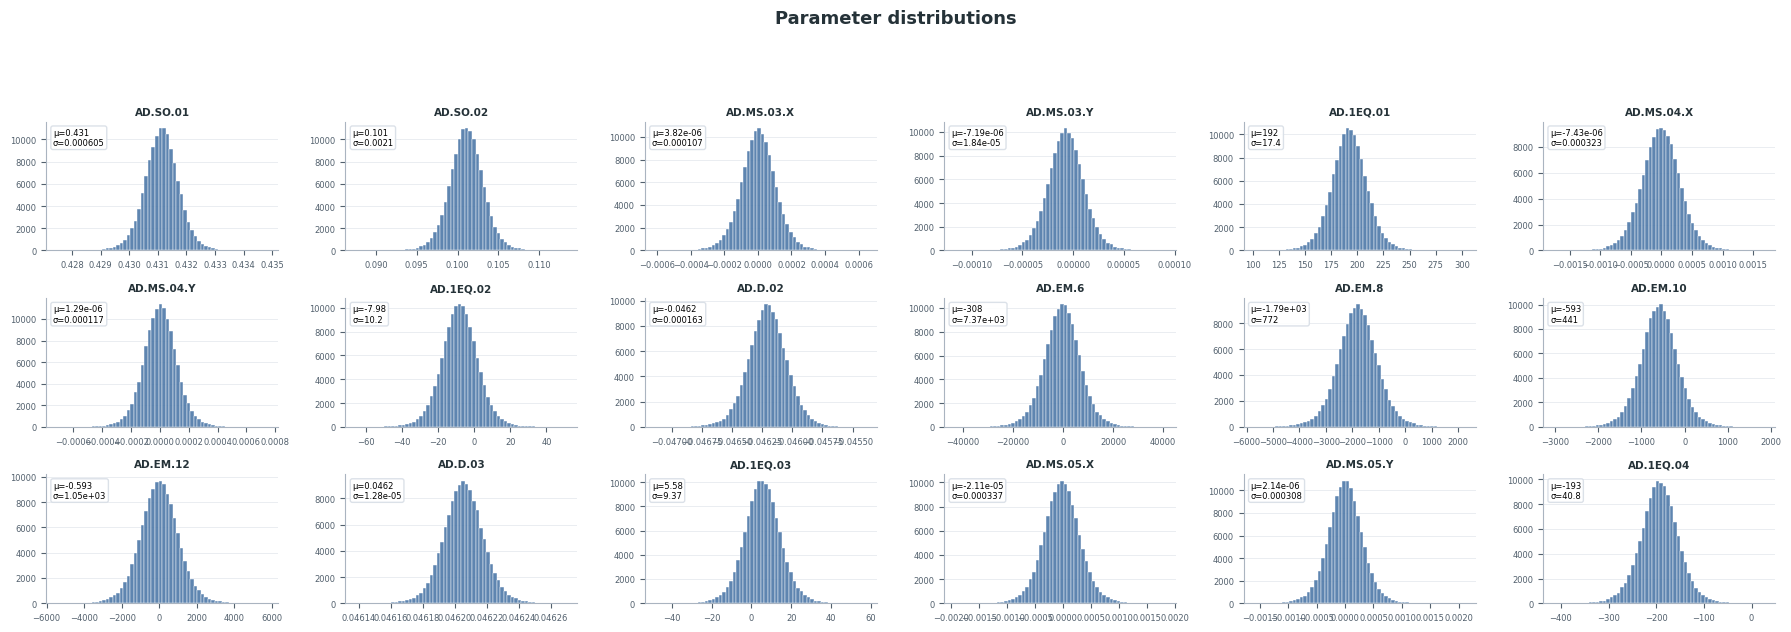

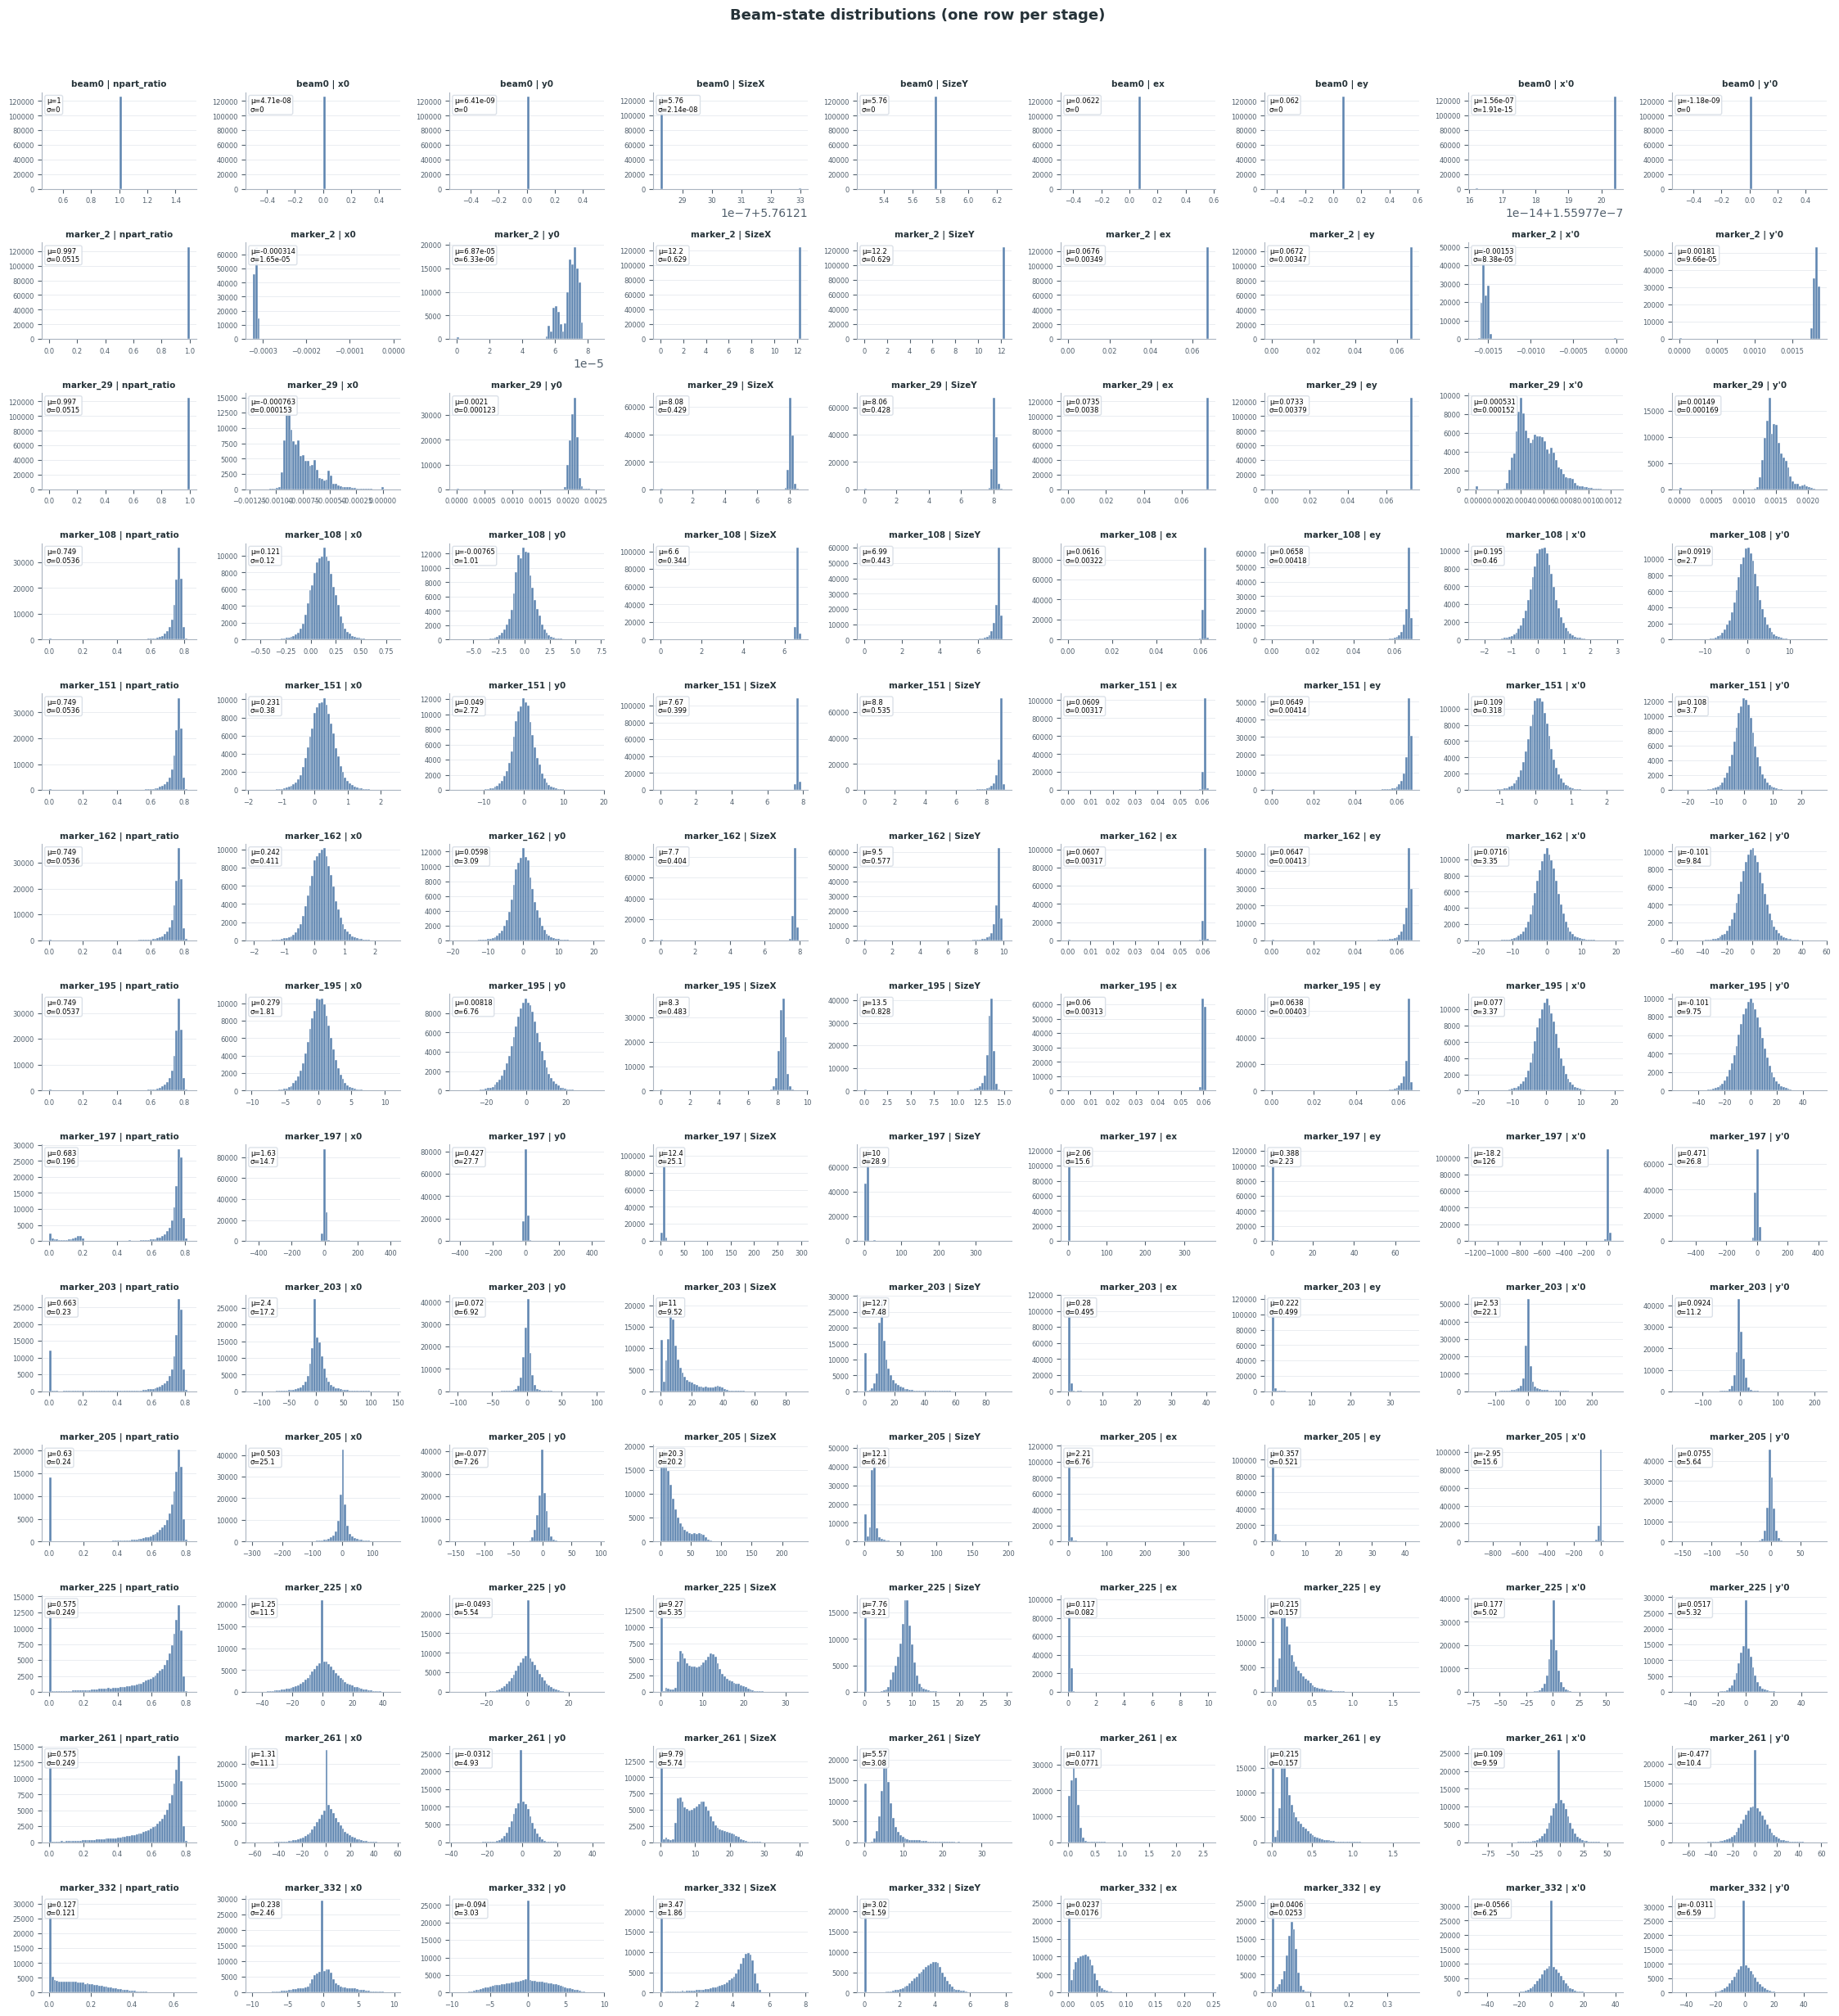

In [6]:
# --- Parameters ---
param_labels = [p.name for p in PARAMETERS]
plot_grid_hist(
    [param_vecs[:, i] for i in range(N_PARAMS)], param_labels,
    'Parameter distributions', ncols=6,
)

# --- Beam states: one grid row per stage (ncols = BEAM_STATE_DIM) ---
beam_labels = [f'{stage_label(s)} | {f}' for s in range(N_STAGES) for f in BEAM_STATE_FEATURES]
beam_data = [beam_stage_arrays[s][:, fi] for s in range(N_STAGES) for fi in range(BEAM_STATE_DIM)]
plot_grid_hist(
    beam_data, beam_labels, 'Beam-state distributions (one row per stage)',
    ncols=BEAM_STATE_DIM, cell_w=2.5, cell_h=1.9,
)

## 4. Score distribution

`DATASET_SCALE` is deliberately calibrated at an 80% (not 100%) success rate (see `exploration_scale_calculation`), so seeing a real fraction of `ERROR_SCORE` ("all particles lost") samples here is by design, not a bug -- it is exactly the ~20% of failure/near-boundary coverage the surrogate is meant to learn from.

Samples: 125844
ERROR_SCORE (-999, all particles lost): 22677 (18.0%)
Valid (non-error) scores: 103167 (82.0%)
  min=-77.0767  max=56.6841  mean=1.93439  std=15.2951
  P05 = -21.8016
  P50 = 1.25384
  P95 = 28.0128


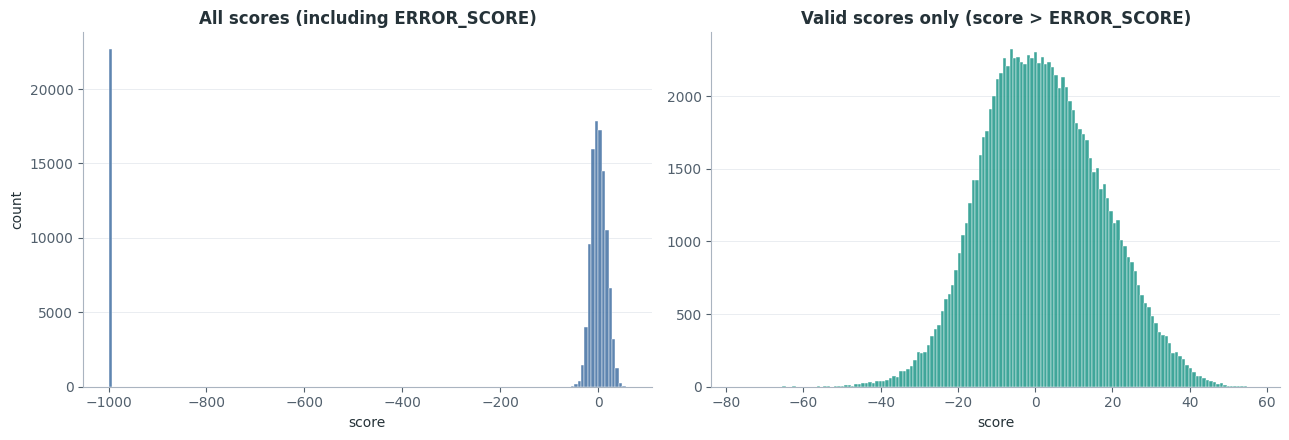

In [7]:
error_mask = scores <= ERROR_SCORE  # sentinel for "all particles lost" (score() clamps to exactly ERROR_SCORE)
n_error = int(error_mask.sum())
valid_scores = scores[~error_mask]

print(f'Samples: {n_samples}')
print(f'ERROR_SCORE ({fmt(ERROR_SCORE)}, all particles lost): {n_error} ({n_error / n_samples:.1%})')
print(f'Valid (non-error) scores: {len(valid_scores)} ({len(valid_scores) / n_samples:.1%})')
if len(valid_scores):
    print(f'  min={fmt(valid_scores.min())}  max={fmt(valid_scores.max())}  '
          f'mean={fmt(valid_scores.mean())}  std={fmt(valid_scores.std())}')
    for p in (5, 50, 95):
        print(f'  P{p:02d} = {fmt(np.percentile(valid_scores, p))}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(scores, bins=150, color=COLORS['blue'], alpha=0.90, edgecolor='white', linewidth=0.35)
axes[0].set_title('All scores (including ERROR_SCORE)')
axes[0].set_xlabel('score'); axes[0].set_ylabel('count'); style_axis(axes[0])
if len(valid_scores):
    axes[1].hist(valid_scores, bins=150, color=COLORS['teal'], alpha=0.90, edgecolor='white', linewidth=0.35)
axes[1].set_title('Valid scores only (score > ERROR_SCORE)')
axes[1].set_xlabel('score'); style_axis(axes[1])
fig.tight_layout()
plt.show()

## 5. Parameter <-> beam-state correlation

One combined Spearman correlation matrix: all `N_PARAMS` parameters (rows) against every beam-state feature at every stage (columns), computed in a single pass -- not one incremental heatmap per stage with a growing parameter subset.

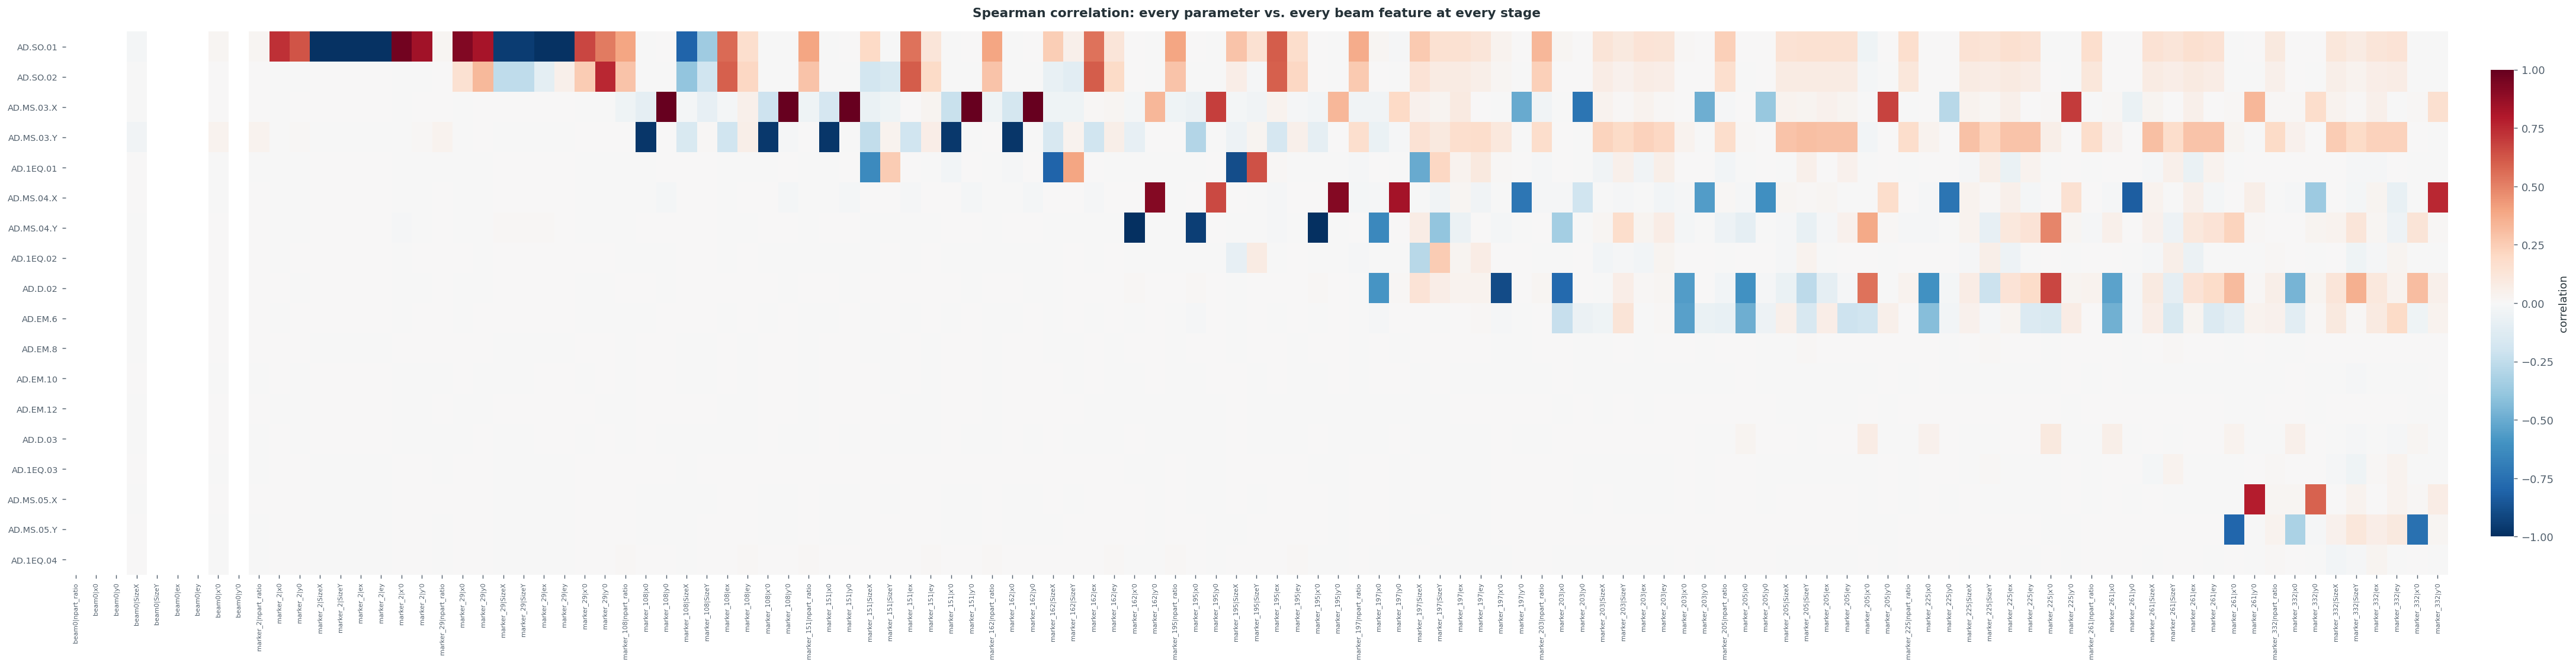

### Strongest parameter <-> beam-feature correlations (top 15 by |ρ|)

| Parameter | Beam feature | Spearman ρ |
| --- | --- | --- |
| AD.MS.03.X | marker_108|y'0 | +0.997 |
| AD.MS.03.X | marker_162|y0 | +0.997 |
| AD.MS.03.X | marker_151|y'0 | +0.997 |
| AD.MS.03.X | marker_151|y0 | +0.997 |
| AD.MS.03.X | marker_108|y0 | +0.997 |
| AD.MS.04.Y | marker_162|x'0 | -0.993 |
| AD.MS.04.Y | marker_195|x'0 | -0.992 |
| AD.SO.01 | marker_2|SizeY | -0.992 |
| AD.SO.01 | marker_2|SizeX | -0.992 |
| AD.SO.01 | marker_2|ey | -0.992 |
| AD.SO.01 | marker_2|ex | -0.992 |
| AD.SO.01 | marker_29|ey | -0.990 |
| AD.SO.01 | marker_29|ex | -0.986 |
| AD.MS.03.Y | marker_108|x0 | -0.976 |
| AD.MS.03.Y | marker_151|x0 | -0.974 |

In [8]:
beam_names = [f'{stage_label(s)}|{f}' for s in range(N_STAGES) for f in BEAM_STATE_FEATURES]
beam_matrix = np.concatenate(beam_stage_arrays, axis=1)  # (N, N_STAGES * BEAM_STATE_DIM)

df_params = pd.DataFrame(param_vecs, columns=[p.name for p in PARAMETERS])
df_beam = pd.DataFrame(beam_matrix, columns=beam_names)
corr = pd.concat([df_params, df_beam], axis=1).corr(method='spearman').loc[df_params.columns, df_beam.columns]

fig, ax = plt.subplots(figsize=(0.30 * len(beam_names) + 3, 0.32 * len(df_params.columns) + 3), dpi=130)
im = ax.imshow(corr.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1,
               interpolation='nearest')
ax.set_xticks(range(len(beam_names)))
ax.set_xticklabels(beam_names, rotation=90, fontsize=6)
ax.set_yticks(range(len(df_params.columns)))
ax.set_yticklabels(df_params.columns, fontsize=8)
ax.set_title('Spearman correlation: every parameter vs. every beam feature at every stage', pad=14)
ax.spines[:].set_visible(False)
colorbar = fig.colorbar(im, ax=ax, label='correlation', shrink=0.86, pad=0.015)
colorbar.outline.set_visible(False)
fig.tight_layout()
plt.show()

flat = corr.stack().reset_index()
flat.columns = ['parameter', 'beam_feature', 'spearman']
flat['abs_corr'] = flat['spearman'].abs()
top = flat.sort_values('abs_corr', ascending=False).head(15)
display(Markdown('### Strongest parameter <-> beam-feature correlations (top 15 by |ρ|)\n\n' + table(
    ['Parameter', 'Beam feature', 'Spearman ρ'],
    [[row.parameter, row.beam_feature, f'{row.spearman:+.3f}'] for row in top.itertuples()],
)))

## 6. Dataset coverage

### Why self mean-KNN distance, in *this* notebook specifically

`render()` (`base_beam_env.py`) already plots a KNN-distance panel for an RL episode's visited
parameters, using `BeamDataset.param_knn_distance()` to say how far the policy strayed from the
training data. Repeating that computation here, on the dataset against *itself*, is not redundant --
it serves two purposes that only make sense at the dataset level:

- **Reference baseline.** A raw number like `KNN=2.3` for one RL-episode step is meaningless on its
  own -- is that close or far? This section's median/P95, computed over points that genuinely *are*
  in the dataset, is exactly the "normal/typical" scale to compare that number against.
- **Dataset self-diagnosis.** Near-zero distances flag likely duplicate/near-duplicate samples (a
  builder bug or insufficient randomness); the extreme upper tail flags isolated outlier points the
  surrogate has essentially no real neighbors to learn from.

Two plots below: (left) mean distance to the five nearest *other* dataset samples, matching the
environment's default `k=5`. It uses the real `dataset.param_knn_distance()` and removes the
mandatory zero-distance self-match analytically, so its sensitivity-normalized values are directly
comparable to the KNN panel and default distance penalty for a visited point; small = densely-sampled
region, large = isolated/sparse region. The right plot is a companion metric, RMS
deviation from `default_params()` in sensitivity units, with a `DATASET_SCALE` reference line -- a
direct sanity check that the dataset was actually generated at its intended calibrated width.

Mean-KNN sensitivity-normalized distance (k=5 other samples; self-match excluded):
  min=1.33662  max=6.70221  mean=2.45769  std=0.711476

RMS deviation from default_params(), in sensitivity units (target ~= DATASET_SCALE = 0.6):
  min=0.232351  max=1.78143  mean=0.701588  std=0.212681


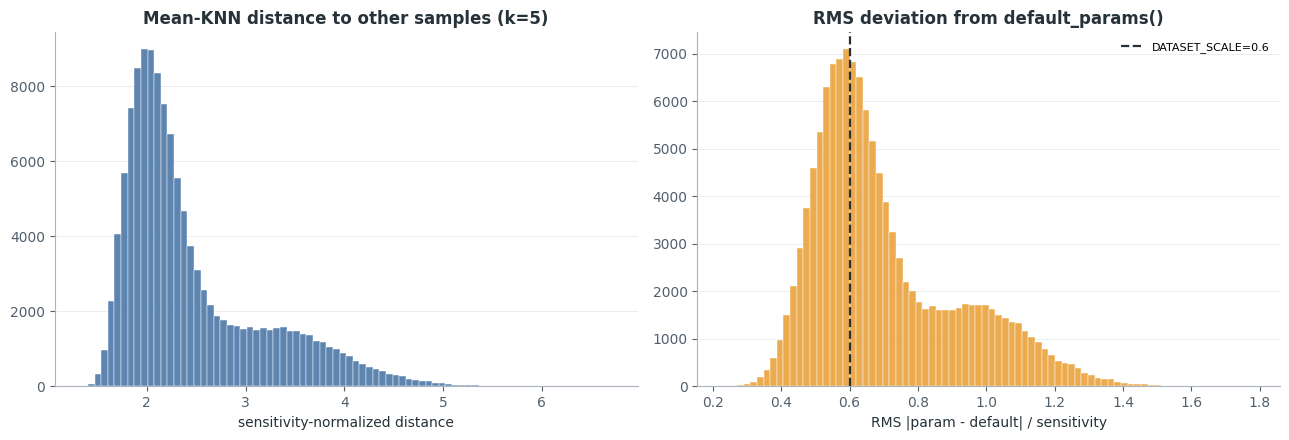

In [9]:
if n_samples < 2:
    raise ValueError('At least two samples are required for KNN coverage diagnostics.')
knn_k = min(5, n_samples - 1)
# Query k+1 because each row finds itself at distance zero. The method returns
# the mean over all k+1 values; multiplying by (k+1)/k removes that zero term
# and yields the mean distance to exactly k other samples.
self_knn_with_zero = dataset.param_knn_distance(param_vecs, k=knn_k + 1)
self_knn = self_knn_with_zero * ((knn_k + 1) / knn_k)

print(f'Mean-KNN sensitivity-normalized distance (k={knn_k} other samples; self-match excluded):')
print(f'  min={fmt(self_knn.min())}  max={fmt(self_knn.max())}  mean={fmt(self_knn.mean())}  std={fmt(self_knn.std())}')

default_vec = params_to_vec(default_params())
normalized_dev = (param_vecs - default_vec) / sens          # (N, N_PARAMS), in sensitivity units
radius = np.sqrt((normalized_dev ** 2).mean(axis=1))          # RMS per-parameter deviation, comparable to DATASET_SCALE

print(f'\nRMS deviation from default_params(), in sensitivity units (target ~= DATASET_SCALE = {fmt(DATASET_SCALE)}):')
print(f'  min={fmt(radius.min())}  max={fmt(radius.max())}  mean={fmt(radius.mean())}  std={fmt(radius.std())}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(self_knn, bins=80, color=COLORS['blue'], alpha=0.90, edgecolor='white', linewidth=0.35)
axes[0].set_title(f'Mean-KNN distance to other samples (k={knn_k})')
axes[0].set_xlabel('sensitivity-normalized distance'); style_axis(axes[0])

axes[1].hist(radius, bins=80, color=COLORS['gold'], alpha=0.90, edgecolor='white', linewidth=0.35)
axes[1].axvline(DATASET_SCALE, color=COLORS['ink'], linewidth=1.6, linestyle='--',
                label=f'DATASET_SCALE={fmt(DATASET_SCALE)}')
axes[1].set_title('RMS deviation from default_params()')
axes[1].set_xlabel('RMS |param - default| / sensitivity'); axes[1].legend(fontsize=8); style_axis(axes[1])
fig.tight_layout()
plt.show()